### All of Statistics | Larry Wasserman | Solutions and Code by David A. Lee
### Chapter 4: Inequalities

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

import sys; sys.path.insert(0, r"C:\Users\david\Documents\math")
from plotstyle import C, FG, BG, savefig, animation_style, saveanim, neon_cmap
SEED = 2024   # each cell starts its own generator from this, so every figure is reproducible on its own

1. Let $X \sim$ Exponential $(\beta)$. Find $\mathbb{P}(|X - \mu_X| \ge k \sigma_X)$ for $k > 1$. Compare this to the bound you get from Chebyshev's inequality.

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_35192\339358297.py:8: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Chebyshev Upper Bound for $X \sim \\text{Exp}(\\beta)$', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_35192\339358297.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbb{P}$', fontsize=16)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap4ex1.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap4\chap4ex1.eps


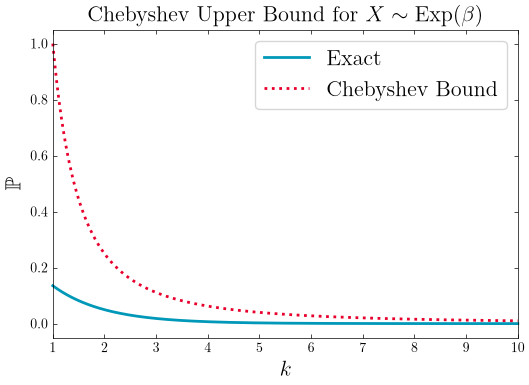

In [2]:
k = np.arange(1,10.01,0.01)
exact = np.exp(-(k+1))
chebyshev = 1 / np.square(k)

plt.figure(figsize=(6,4))
plt.plot(k, exact, zorder=2, linewidth=2, color=C.cyan, clip_on=False, label='Exact') 
plt.plot(k, chebyshev, zorder=2, linewidth=2, linestyle='dotted', color=C.red, clip_on=False, label='Chebyshev Bound') 
plt.title('Chebyshev Upper Bound for $X \sim \\text{Exp}(\\beta)$', fontsize=16)
plt.xlabel('$k$', fontsize=16)
plt.ylabel('$\mathbb{P}$', fontsize=16)
plt.xlim([1, 10])
plt.minorticks_off()
plt.legend(loc= 'upper right', frameon=True, fontsize=16)

savefig(plt.gcf(), 'chap4ex1.eps', bbox_inches=None)
plt.show()

4. Let $X_1, ..., X_n \sim$ Bernoulli $(p)$.

(a) Let $\alpha > 0$ be fixed and define
$$
    \epsilon_n = \sqrt{\frac{1}{2n} \log\left(\frac{2}{\alpha}\right)}
$$
Let $\widehat{p}_n = n^{-1} \sum^n_{i=1} X_i$. Define $C_n = (\widehat{p}_n - \epsilon_n, \widehat{p}_n + \epsilon_n)$. Use Hoeffding's inequality to show that
$$
    \mathbb{P}(C_n \text{ contains } p) \ge 1 - \alpha
$$
In practice, we truncate the interval so it does not go below 0 or above 1.

(b) (Computer Experiment.) Let's examine the properties of this confidence interval. Let $\alpha = 0.05$ and $p = 0.4$. Conduct a simulation study to see how often the interval contains $p$ (called the coverage). Do this for various values of $n$ between 1 and 10000. Plot the coverage versus $n$.

(c) Plot the length of the interval versus $n$. Suppose we want the length of the interval to be no more than $.05$. How large should $n$ be?


<>:21: SyntaxWarning: invalid escape sequence '\w'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\w'
<>:23: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_35192\3064009868.py:21: SyntaxWarning: invalid escape sequence '\w'
  plt.title('Coverage ({} samples of $\widehat{{p}}_n$)'.format(k), fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_35192\3064009868.py:23: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbb{P}(C_n \\text{ contains } p)$', fontsize=16)
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap4ex4b.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap4\chap4ex4b.eps


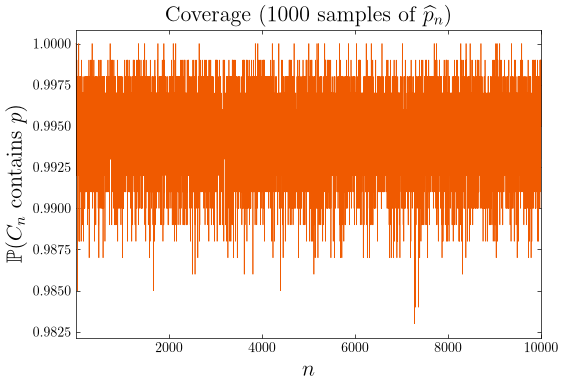

In [3]:
rng = np.random.default_rng(SEED)
k, n = 1000, 10000 # number of samples, number of variables
alpha = 0.05
eps = np.sqrt((1/(2*n))*np.log(2/alpha))
p = 0.4

def confinttest(k,n): # test if p is in confidence interval; argument is k number of samples, n number of variables
    s = rng.binomial(n, p, size=k)/n   # k values of p-hat_n: the mean of n Bernoulli(p) is Binomial(n, p)/n
    epsn = np.sqrt((1/(2*n))*np.log(2/alpha))   # the interval half-width for this n
    return (p > s - epsn) & (p < s + epsn);

def coverage():
    coverage = []
    for i in range(1,n+1):
        count = np.count_nonzero(confinttest(k,i) == True)
        coverage.append(count / k)
    return coverage;

plt.figure(figsize=(6,4))
plt.plot(list(range(1,n+1)), coverage(), zorder=2, linewidth=0.5, color=C.orange, clip_on=False) 
plt.title('Coverage ({} samples of $\widehat{{p}}_n$)'.format(k), fontsize=16)
plt.xlabel('$n$', fontsize=16)
plt.ylabel('$\mathbb{P}(C_n \\text{ contains } p)$', fontsize=16)
plt.xlim([1, n])
plt.minorticks_off()

savefig(plt.gcf(), 'chap4ex4b.eps', bbox_inches=None)
plt.show()



<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
C:\Users\david\AppData\Local\Temp\ipykernel_35192\54206432.py:16: SyntaxWarning: invalid escape sequence '\e'
  plt.title('$\epsilon_n$', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_35192\54206432.py:19: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('$\epsilon_n$', fontsize=16)
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap4ex4c.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap4\chap4ex4c.eps


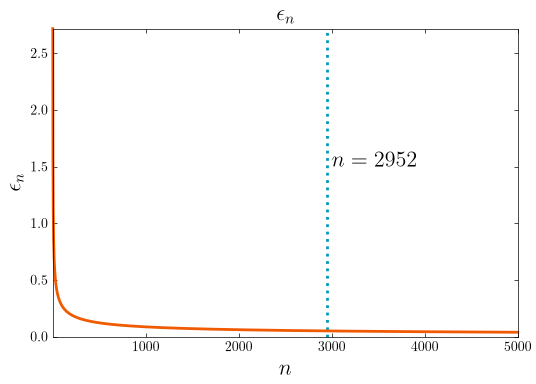

In [4]:
# plotting 2*eps versus n

def intlength(n):
    epsilons = np.empty(n)
    for i in range(1,n+1):
        epsilon = np.sqrt((1/(2*i))*np.log(2/alpha))
        epsilons[i-1] = 2*epsilon
    return epsilons;

n = 5000
nsolution = np.argwhere(intlength(n) < 0.05).min() + 1

plt.figure(figsize=(6,4))
plt.plot(list(range(1,n+1)), intlength(n), zorder=2, linewidth=2, color=C.orange, clip_on=False) 
plt.axvline(nsolution, color=C.cyan, linestyle='dotted', linewidth=2, zorder=1, clip_on=False)
plt.title('$\epsilon_n$', fontsize=16)
plt.text(3000, 1.5,'$n = {}$'.format(nsolution), fontsize=16)
plt.xlabel('$n$', fontsize=16)
plt.ylabel('$\epsilon_n$', fontsize=16)
plt.xlim([1, n])
plt.ylim([0,intlength(n).max()])
plt.minorticks_off()

savefig(plt.gcf(), 'chap4ex4c.eps', bbox_inches=None)
plt.show()

6. Let $Z \sim N(0,1)$. Find $\mathbb{P}(|Z| > t)$ and plot this as a function of $t$. From Markov's inequality, we have the bound $\mathbb{P}(|Z| > t) \le \frac{\mathbb{E}|Z|^{k}}{t^k}$ for any $k > 0$. Plot these bounds for $k = 1, 2, 3, 4, 5$ and compare them to the true value of $\mathbb{P}(|Z| > t)$. Also, plot the bound from Mill's inequality.

<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_35192\340408216.py:61: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbb{P}(|Z| > t)$', fontsize=16)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap4ex6.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap4\chap4ex6.eps


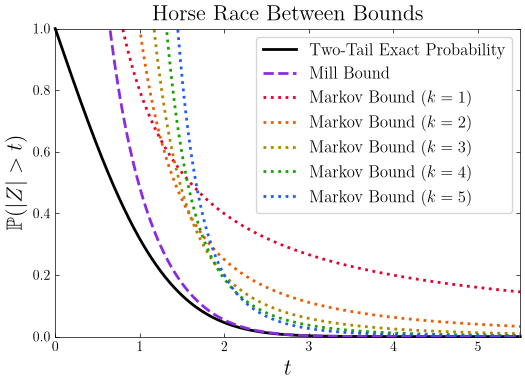

In [5]:
# P(|Z| > t) looks at the two-tailed probabilities, namely the probability that Z is > t or < -t. By symmetry of the standard normal distribution, we can calculate 2(1 - F(t)) to get this probability.

from scipy.stats import norm
import math


def normtest(t): # two-tailed probabilities, argument is threshold t for delimiting the tails
    normal_dist = norm(0,1)
    domain = np.arange(0,t+0.01,0.01)
    probs = np.empty(len(domain))
    for i, j in zip(domain, range(0, len(domain))):
        probs[j] = (2*(1-normal_dist.cdf(i)))
    return probs;

def markov(k, t): # Markov bound, argument k is power of the bound, and t for delimiting the tails
    domain = np.arange(0.01,t+0.01,0.01)
    markovs = np.empty(len(domain))
    exptabszk = 2**(k/2)*math.gamma((k+1)/2)/math.sqrt(math.pi)   # E|Z|^k, exactly
    for i, j in zip(domain, range(0, len(domain))):
        markovs[j] = np.divide(exptabszk, np.power(i,k))
    return markovs;

def mill(t): # Mill bound, argument t for delimiting the tails
    domain = np.arange(0.01,t+0.01,0.01)
    mills = np.empty(len(domain))
    for i, j in zip(domain, range(0, len(domain))):
        mills[j] = np.sqrt(2 / math.pi)*(np.exp(-np.square(i)/2)/i)
    return mills;

t = 5.5

plt.figure(figsize=(6,4))
plt.plot(np.arange(0,t+0.01,0.01), normtest(t), linewidth=2, color=FG, clip_on=False, label='Two-Tail Exact Probability') 

# Plotting Mill bound
milldomain = np.arange(0.01,t+0.01,0.01)
millbound = mill(t)
millconcat = millbound[millbound <= 1]
millindex = np.where(millbound == millconcat[0])[0][0]

plt.plot(np.arange(milldomain[millindex],t+0.01,0.01), millconcat, linestyle='dashed', linewidth=2, color=C.violet, clip_on=False, label='Mill Bound')

# Plotting Markov bounds. All of this is to chop of the Markov bound plots where they exceed the plot limits.
# With matplotlib, it looks like we have to preprocess the data in this manner.
# If there is an easier way to do this, I want to know!

kays = [k1, k2, k3, k4, k5] = [i for i in range(1,6)]
markovs = [markov1, markov2, markov3, markov4, markov5] = [markov(i,t) for i in kays]
markovdomain = np.arange(0.01,t+0.01,0.01)
concats = [i[i <= 1] for i in markovs]
indices = [np.where(i == j[0])[0][0] for i, j in zip(markovs, concats)]
colors = [C.red,C.orange,C.yellow,C.green,C.blue]

for i, j, k, l in zip(indices, concats, range(1,6), colors):
    plt.plot(np.arange(markovdomain[i],t+0.01,0.01), j, linestyle='dotted', linewidth=2, color=l, clip_on=False, label='Markov Bound ($k = {}$)'.format(k)) 

# plt.plot(np.arange(markovdomain[markovindex],t+0.01,0.01), concatenatemarkov, linestyle='dotted', linewidth=2, color=C.cyan, clip_on=False, label='Markov Bound ($k = 1$)') 

plt.title('Horse Race Between Bounds', fontsize=16)
plt.xlabel('$t$', fontsize=16)
plt.ylabel('$\mathbb{P}(|Z| > t)$', fontsize=16)
plt.xlim([0,t])
plt.ylim([0,1])
plt.minorticks_off()
plt.legend(loc= 'upper right', frameon=True, fontsize=12)

savefig(plt.gcf(), 'chap4ex6.eps', bbox_inches=None)
plt.show()